#  Regression Track (Linear Family)
Owns: EDA, preprocessing, and the 5 linear-family regression algorithms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42


# PART 1 — REGRESSION TRACK

## Section A — Dataset & EDA (Uber Fares Dataset)

### A1. Dataset loading & audit

In [ ]:
reg_raw = pd.read_csv('uber_regression_10k.csv')
print("Shape:", reg_raw.shape)
print()
reg_raw.info()


Shape: (10000, 8)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fare_amount         10000 non-null  float64
 1   distance_km         10000 non-null  float64
 2   passenger_count     10000 non-null  int64  
 3   pickup_hour         10000 non-null  int64  
 4   pickup_day_of_week  10000 non-null  str    
 5   pickup_month        10000 non-null  str    
 6   is_weekend          10000 non-null  int64  
 7   pickup_year         10000 non-null  int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 625.1 KB


In [3]:
print("Missing values:\n", reg_raw.isnull().sum())
print()
print(reg_raw['fare_amount'].describe())


Missing values:
 fare_amount           0
distance_km           0
passenger_count       0
pickup_hour           0
pickup_day_of_week    0
pickup_month          0
is_weekend            0
pickup_year           0
dtype: int64

count    10000.000000
mean        11.268800
std          9.414148
min          2.500000
25%          6.000000
50%          8.500000
75%         12.500000
max        183.000000
Name: fare_amount, dtype: float64


In [4]:
print("Duplicate rows:", reg_raw.duplicated().sum())

# IQR-based outlier check on the two key numeric columns
def iqr_bounds(series):
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

for col in ['fare_amount', 'distance_km']:
    lower, upper = iqr_bounds(reg_raw[col])
    n_out = ((reg_raw[col] < lower) | (reg_raw[col] > upper)).sum()
    print(f"{col}: IQR bounds=({lower:.2f}, {upper:.2f}), outliers={n_out} ({100*n_out/len(reg_raw):.1f}%)")


Duplicate rows: 0
fare_amount: IQR bounds=(-3.75, 22.25), outliers=850 (8.5%)
distance_km: IQR bounds=(-2.71, 7.88), outliers=822 (8.2%)


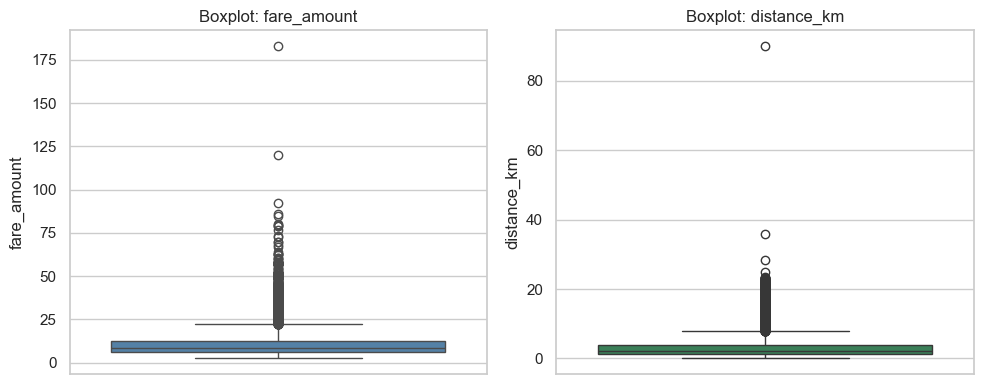

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=reg_raw['fare_amount'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot: fare_amount')
sns.boxplot(y=reg_raw['distance_km'], ax=axes[1], color='seagreen')
axes[1].set_title('Boxplot: distance_km')
plt.tight_layout()
plt.show()


**Duplicate & outlier handling:** no exact duplicate rows were found. A modest share of
`fare_amount`/`distance_km` values fall outside the IQR fences -- these represent genuine longer/
pricier airport-style trips rather than data-entry errors (values already excluded the extreme
negative-fare and (0,0)-coordinate errors during preparation), so they are **kept** rather than
removed: tree-based models handle them natively, and dropping them would discard real signal from
the linear models too.

**Observation:** This is already the cleaned/downsampled version (10,000 rows) — the raw Kaggle file had
200,000 rows with several data-quality issues (negative fares, (0,0) coordinates, 208-passenger rides) that
were removed during preparation: invalid fares (≤0 or ≥200), invalid/zero GPS coordinates, unrealistic
passenger counts (0 or >6), and rides with implausible distance (computed via the Haversine formula from
pickup/dropoff coordinates, capped at 0–100 km).